# Subglacial Lakes

- Subglacial Lakes
    * Description: 85 active Antarctic subglacial lakes detected from a decade of CryoSat-2 radar altimetry. Documenting draining and filling events and time-varying boundaries of subglacial lake activity. Ice surface elevation change (dz) for the period October 2010 to July 2020.
    * Original Data Source: https://zenodo.org/records/16330565
    * Reference: https://www.nature.com/articles/s41467-025-63773-9
    * OSC entry: https://opensciencedata.esa.int/products/subglacial-lakes-boundries/collection
    * License: CC-BY-4.0
    * Repo Folder: ./datasets/subglacial_lakes

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
antarctic_crs = ccrs.SouthPolarStereo(
    central_longitude=0,
    true_scale_latitude=-71,
)

In [3]:
# Read the subglacial lakes boundaries
bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
file = 'OSCAssets/polar_cube_datasets/subglacial_lakes/subglacial_lakes_boundries.parquet'


gdf = gpd.read_parquet(
    f"{bucket}{file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    }
)

gdf['area'] = gdf.area
gdf

/tmp/ipykernel_18956/3385685713.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area'] = gdf.area


,record_id,name,new_sgl_glake,start_date,end_date,contour_m_yr,geometry,area
0,Byrd_10_201107-201609_0.6,Byrd_10,False,2011-07-01,2016-09-01,0.6,"POLYGON ((-145.693 -79.91919, -145.66116 -79.9...",0.058747
1,Jutulstraumen_74_201509-202007_0.5,Jutulstraumen_74,False,2015-09-01,2020-07-01,0.5,"POLYGON ((149.03818 -70.90299, 149.03017 -70.8...",0.036503
2,Borchgrevink_198_201412-202007_0.3,Borchgrevink_198,False,2014-12-01,2020-07-01,0.3,"POLYGON ((155.3791 -75.47119, 155.36316 -75.46...",0.058957
3,Totten_36_201202-202007_0.1,Totten_36,False,2012-02-01,2020-07-01,0.1,"POLYGON ((-148.9065 -84.70493, -148.91801 -84....",0.115222
4,Academy_45_201512-202007_0.4,Academy_45,False,2015-12-01,2020-07-01,0.4,"POLYGON ((-83.90481 -78.1871, -83.90071 -78.19...",0.052464
...,...,...,...,...,...,...,...,...
151,Mercer2_201402_201807_0.8,Mercer2,True,2014-02-01,2018-07-01,0.8,"POLYGON ((148.152 -68.57873, 148.14392 -68.575...",0.003852
152,Mac3_201209_201904_0.3,Mac3,True,2012-09-01,2019-04-01,0.3,"POLYGON ((112.56294 -67.59883, 112.5586 -67.59...",0.007689
153,THW170_201605_201902_0.8,THW170,True,2016-05-01,2019-02-01,0.8,"POLYGON ((-120.11364 -75.35571, -120.10997 -75...",0.008920
154,Institute_E1b_201402_201804_0.4,Institute_E1b,True,2014-02-01,2018-04-01,0.4,"POLYGON ((110.71122 -66.84517, 110.70411 -66.8...",0.001522


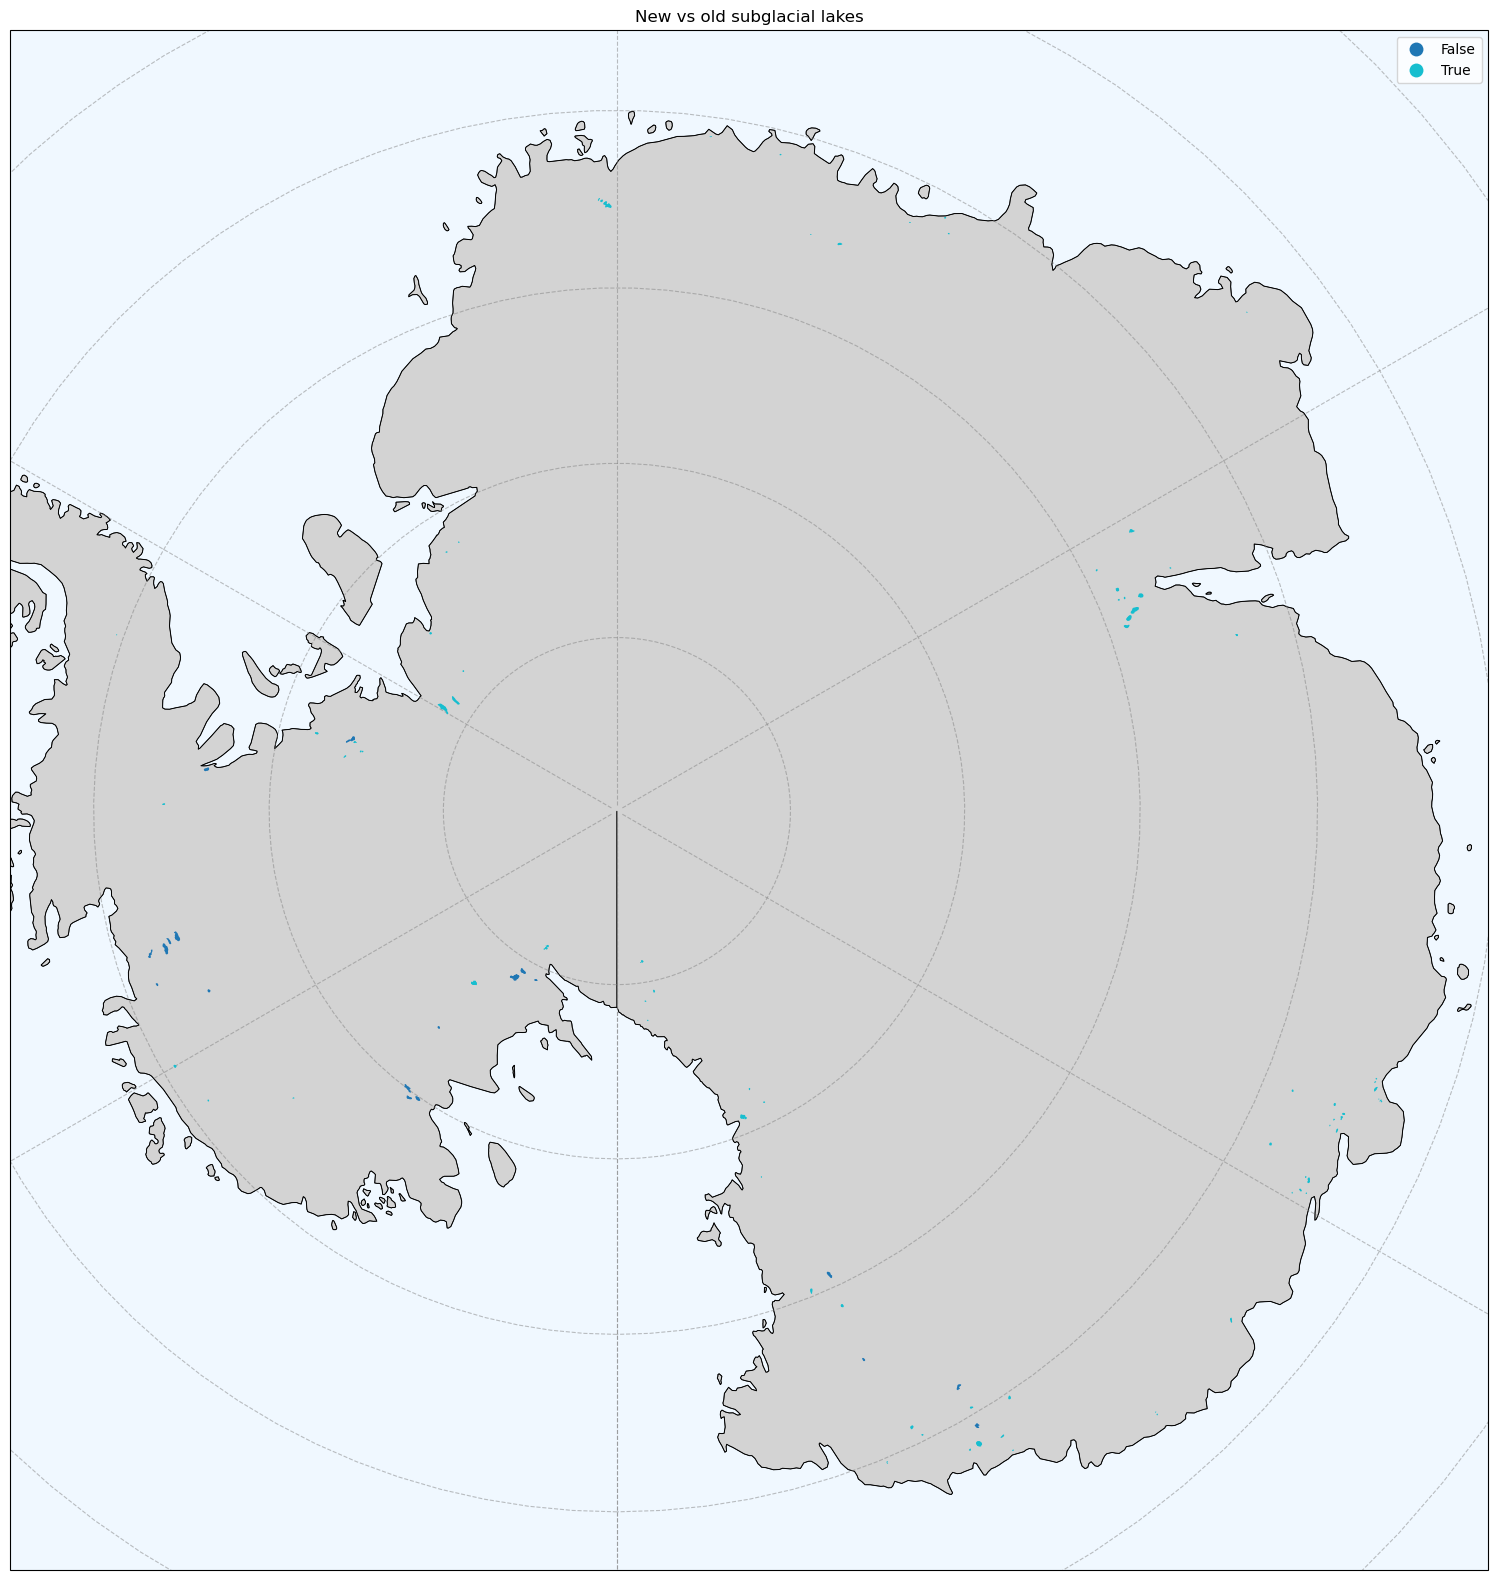

In [4]:
gdf_3031 = gdf.to_crs(epsg=3031)

fig, ax = plt.subplots(
    figsize=(20, 20),
    subplot_kw={"projection": antarctic_crs},
)

ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", linewidth=0.4, zorder=1)
ax.coastlines(resolution="50m", color="black", linewidth=0.7, zorder=2)
ax.gridlines(draw_labels=False, color="gray", alpha=0.5, linestyle="--")

gdf_3031.plot(column="new_sgl_glake", legend=True, ax=ax, zorder=3)

minx, miny, maxx, maxy = gdf_3031.total_bounds
pad = max(maxx - minx, maxy - miny) * 0.08
ax.set_extent([minx - pad, maxx + pad, miny - pad, maxy + pad], crs=antarctic_crs)

ax.set_title("New vs old subglacial lakes")
plt.show()